# Beer Data Explorer

dunnhumby.db の Beer 関連テーブルにアクセスし、データの把握と可視化を行う。

| テーブル | 行数 | 内容 |
|---------|-----:|------|
| beer_transactions | 17,807 | 購買明細 |
| beer_weekly_brand | 2,409 | 週×ブランド別集計 |
| beer_weekly_total | 102 | 週別合計 |

In [7]:
using SQLite, DataFrames, Statistics, Printf, Plots

In [2]:
DB_PATH = raw"C:\Users\kimse\OneDrive\Jupyter_notebook\dunnhumby.db"
db = SQLite.DB(DB_PATH)
println("Connected: ", DB_PATH)

Connected: C:\Users\kimse\OneDrive\Jupyter_notebook\dunnhumby.db


## 1. データ読み込み

In [3]:
# 購買明細
beer_tx = DBInterface.execute(db, """
    SELECT week_no, day, household_key, brand,
           CAST(quantity AS INTEGER) AS quantity,
           CAST(sales_value AS REAL) AS sales_value,
           CAST(unit_price AS REAL) AS unit_price,
           CAST(promo AS INTEGER) AS promo
    FROM beer_transactions
    ORDER BY week_no, day
""") |> DataFrame

# 週×ブランド別集計
beer_wb = DBInterface.execute(db, """
    SELECT week_no, brand,
           CAST(total_sales AS REAL) AS total_sales,
           CAST(total_qty AS INTEGER) AS total_qty,
           CAST(n_transactions AS INTEGER) AS n_transactions,
           CAST(avg_unit_price AS REAL) AS avg_unit_price,
           CAST(promo_rate AS REAL) AS promo_rate,
           CAST(n_households AS INTEGER) AS n_households
    FROM beer_weekly_brand
    ORDER BY week_no, brand
""") |> DataFrame

# 週別合計
beer_wt = DBInterface.execute(db, """
    SELECT week_no,
           CAST(total_sales AS REAL) AS total_sales,
           CAST(total_qty AS INTEGER) AS total_qty,
           CAST(n_transactions AS INTEGER) AS n_transactions,
           CAST(promo_rate AS REAL) AS promo_rate,
           CAST(n_households AS INTEGER) AS n_households
    FROM beer_weekly_total
    ORDER BY week_no
""") |> DataFrame

@printf("beer_transactions: %d rows\n", nrow(beer_tx))
@printf("beer_weekly_brand: %d rows\n", nrow(beer_wb))
@printf("beer_weekly_total: %d rows\n", nrow(beer_wt))

beer_transactions: 17807 rows
beer_weekly_brand: 2409 rows
beer_weekly_total: 102 rows


## 2. 基本統計

In [4]:
println("=== beer_transactions 概要 ===")
@printf("期間:           week %d ~ %d (%d weeks)\n",
    minimum(beer_tx.week_no), maximum(beer_tx.week_no),
    length(unique(beer_tx.week_no)))
@printf("レコード数:     %d\n", nrow(beer_tx))
@printf("ユニーク世帯:   %d\n", length(unique(beer_tx.household_key)))
@printf("ブランド数:     %d\n", length(unique(beer_tx.brand)))
@printf("数量 合計:      %d\n", sum(beer_tx.quantity))
@printf("売上 合計:      \$%.2f\n", sum(beer_tx.sales_value))
@printf("単価 平均:      \$%.2f  中央値: \$%.2f\n",
    mean(beer_tx.unit_price), median(beer_tx.unit_price))
@printf("プロモあり:     %d / %d (%.1f%%)\n",
    sum(beer_tx.promo), nrow(beer_tx),
    100.0 * sum(beer_tx.promo) / nrow(beer_tx))

=== beer_transactions 概要 ===
期間:           week 1 ~ 102 (102 weeks)
レコード数:     17807
ユニーク世帯:   1606
ブランド数:     87
数量 合計:      19860
売上 合計:      $147309.68
単価 平均:      $7.76  中央値: $7.49
プロモあり:     3440 / 17807 (19.3%)


In [5]:
describe(beer_tx[:, [:quantity, :sales_value, :unit_price, :promo]])

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Float64,Real,Float64,Real,Int64,DataType
1,quantity,1.11529,0,1.0,13,0,Int64
2,sales_value,8.27257,0.0,7.49,115.43,0,Float64
3,unit_price,7.75892,0.0,7.49,20.99,0,Float64
4,promo,0.193182,0,0.0,1,0,Int64


## 3. ブランド別分析

In [6]:
# ブランド別サマリ（上位20）
brand_stats = combine(groupby(beer_tx, :brand),
    nrow => :n_tx,
    :sales_value => sum => :total_sales,
    :quantity => sum => :total_qty,
    :unit_price => mean => :avg_price,
    :promo => mean => :promo_rate,
    :household_key => (x -> length(unique(x))) => :n_hh,
    :week_no => (x -> length(unique(x))) => :n_weeks
)
sort!(brand_stats, :total_sales, rev=true)
brand_stats.avg_price = round.(brand_stats.avg_price, digits=2)
brand_stats.promo_rate = round.(brand_stats.promo_rate, digits=3)
brand_stats.total_sales = round.(brand_stats.total_sales, digits=2)
first(brand_stats, 20)

Row,brand,n_tx,total_sales,total_qty,avg_price,promo_rate,n_hh,n_weeks
,String,Int64,Float64,Int64,Float64,Float64,Int64,Int64
1,239,7534,65722.1,8362,8.18,0.234,1113,102
2,697,4227,32260.0,4782,7.2,0.198,664,101
3,1728,1410,13100.2,1511,8.7,0.207,375,102
4,2343,564,6042.1,621,9.85,0.241,256,99
5,1830,414,4459.88,453,10.02,0.196,157,99
6,2384,405,3211.76,424,7.64,0.22,230,100
7,2558,335,3144.44,346,9.02,0.158,132,94
8,5221,351,2584.08,372,6.99,0.251,180,88
9,2431,220,1860.39,231,8.13,0.073,105,83


In [8]:
# 上位ブランドのシェア
total_sales_all = sum(brand_stats.total_sales)
brand_stats.share_pct = round.(100.0 .* brand_stats.total_sales ./ total_sales_all, digits=1)
brand_stats.cum_share = round.(cumsum(brand_stats.share_pct), digits=1)
println("売上シェア（上位10ブランド）:")
first(brand_stats[:, [:brand, :total_sales, :share_pct, :cum_share]], 10)

売上シェア（上位10ブランド）:


Row,brand,total_sales,share_pct,cum_share
,String,Float64,Float64,Float64
1,239,65722.1,44.6,44.6
2,697,32260.0,21.9,66.5
3,1728,13100.2,8.9,75.4
4,2343,6042.1,4.1,79.5
5,1830,4459.88,3.0,82.5
6,2384,3211.76,2.2,84.7
7,2558,3144.44,2.1,86.8
8,5221,2584.08,1.8,88.6
9,2431,1860.39,1.3,89.9


## 4. 週次トレンド

In [9]:
using StatsPlots
gr(size=(900, 400))

Plots.GRBackend()

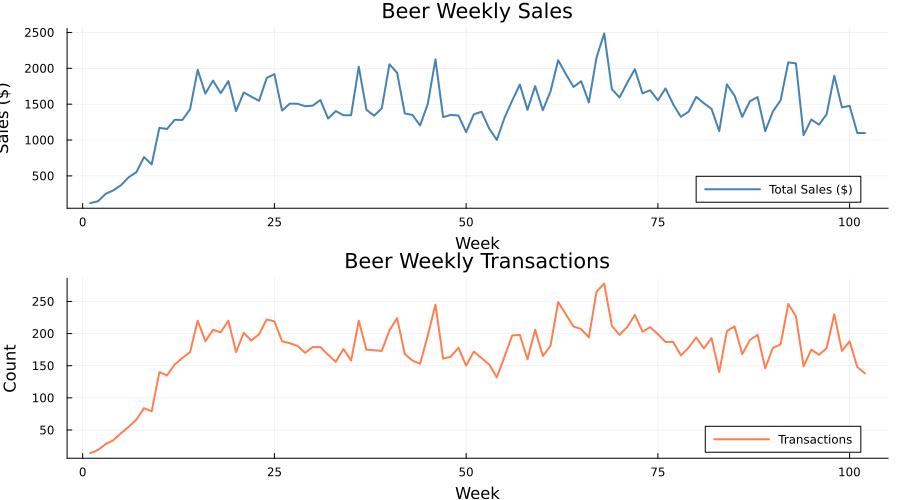

In [10]:
# 週別売上・取引数
p1 = plot(beer_wt.week_no, beer_wt.total_sales,
    label="Total Sales (\$)", lw=2, color=:steelblue,
    xlabel="Week", ylabel="Sales (\$)",
    title="Beer Weekly Sales")

p2 = plot(beer_wt.week_no, beer_wt.n_transactions,
    label="Transactions", lw=2, color=:coral,
    xlabel="Week", ylabel="Count",
    title="Beer Weekly Transactions")

plot(p1, p2, layout=(2,1), size=(900, 500))

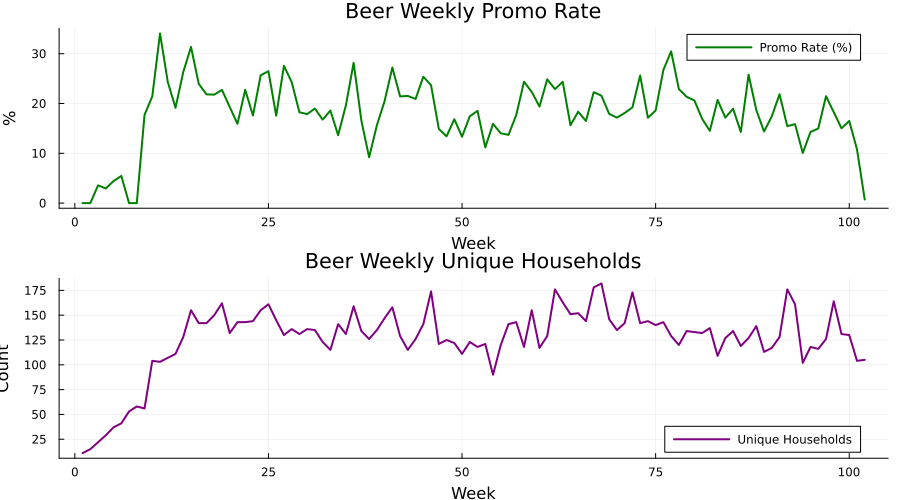

In [11]:
# 週別プロモ率と世帯数
p3 = plot(beer_wt.week_no, beer_wt.promo_rate .* 100,
    label="Promo Rate (%)", lw=2, color=:green,
    xlabel="Week", ylabel="%",
    title="Beer Weekly Promo Rate")

p4 = plot(beer_wt.week_no, beer_wt.n_households,
    label="Unique Households", lw=2, color=:purple,
    xlabel="Week", ylabel="Count",
    title="Beer Weekly Unique Households")

plot(p3, p4, layout=(2,1), size=(900, 500))

## 5. 上位ブランドの週次推移

Top 5 brands: ["239", "697", "1728", "2343", "1830"]


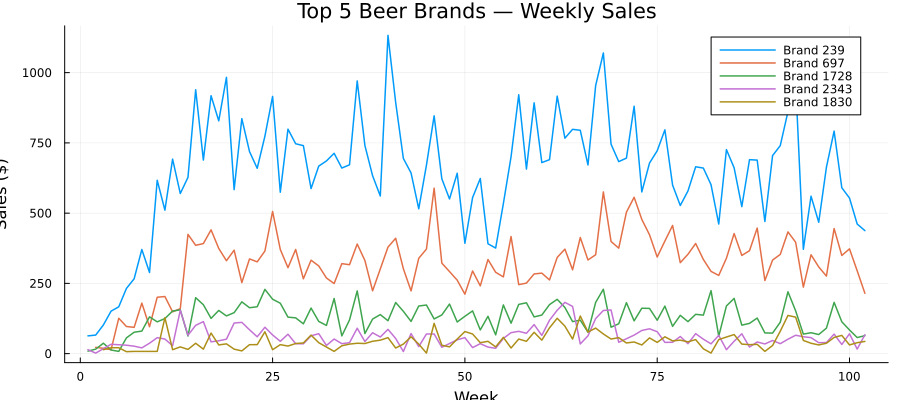

In [12]:
# 売上上位5ブランド
top5 = first(brand_stats, 5).brand
println("Top 5 brands: ", top5)

p = plot(xlabel="Week", ylabel="Sales (\$)",
    title="Top 5 Beer Brands — Weekly Sales", legend=:topright,
    size=(900, 400))
for b in top5
    sub = filter(r -> r.brand == b, beer_wb)
    plot!(p, sub.week_no, sub.total_sales, label="Brand $b", lw=1.5)
end
p

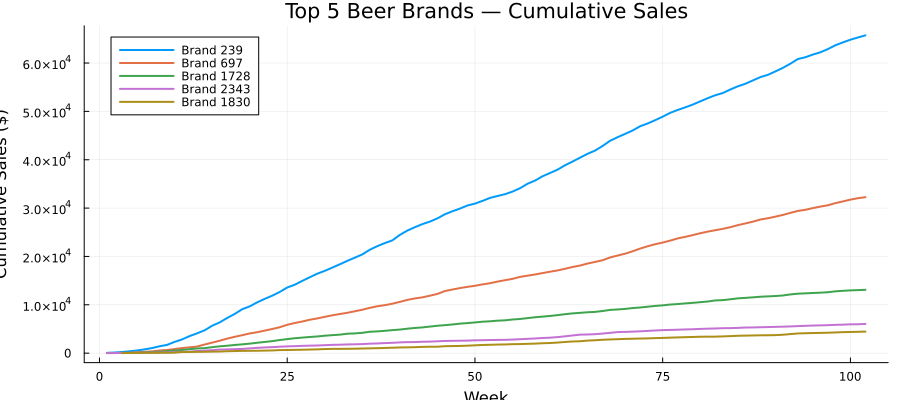

In [13]:
# 上位5ブランドの累積売上
p = plot(xlabel="Week", ylabel="Cumulative Sales (\$)",
    title="Top 5 Beer Brands — Cumulative Sales", legend=:topleft,
    size=(900, 400))
for b in top5
    sub = sort(filter(r -> r.brand == b, beer_wb), :week_no)
    plot!(p, sub.week_no, cumsum(sub.total_sales), label="Brand $b", lw=2)
end
p

## 6. プロモーション効果の概観

In [14]:
# プロモあり/なし別の購買比較
promo_comp = combine(groupby(beer_tx, :promo),
    nrow => :n_transactions,
    :quantity => mean => :avg_qty,
    :sales_value => mean => :avg_sales,
    :unit_price => mean => :avg_price,
    :household_key => (x -> length(unique(x))) => :n_hh
)
promo_comp.avg_qty = round.(promo_comp.avg_qty, digits=2)
promo_comp.avg_sales = round.(promo_comp.avg_sales, digits=2)
promo_comp.avg_price = round.(promo_comp.avg_price, digits=2)
promo_comp

Row,promo,n_transactions,avg_qty,avg_sales,avg_price,n_hh
,Int64,Int64,Float64,Float64,Float64,Int64
1,0,14367,1.13,7.36,6.94,1510
2,1,3440,1.07,12.1,11.19,856


In [15]:
# ブランド別プロモ効果（上位10ブランド）
top10 = first(brand_stats, 10).brand
top_tx = filter(r -> r.brand in top10, beer_tx)

promo_by_brand = combine(groupby(top_tx, [:brand, :promo]),
    nrow => :n_tx,
    :sales_value => mean => :avg_sales,
    :unit_price => mean => :avg_price
)
promo_by_brand.avg_sales = round.(promo_by_brand.avg_sales, digits=2)
promo_by_brand.avg_price = round.(promo_by_brand.avg_price, digits=2)
sort!(promo_by_brand, [:brand, :promo])
promo_by_brand

Row,brand,promo,n_tx,avg_sales,avg_price
,String,Int64,Int64,Float64,Float64
1,1465,0,183,7.41,7.17
2,1465,1,6,7.66,7.66
3,1728,0,1118,8.49,7.96
4,1728,1,292,12.36,11.52
5,1830,0,333,10.22,9.59
6,1830,1,81,13.05,11.75
7,2343,0,428,9.99,9.16
8,2343,1,136,12.98,12.0
9,2384,0,316,7.81,7.51


## 7. 世帯購買パターン

In [16]:
# 世帯別購買頻度
hh_freq = combine(groupby(beer_tx, :household_key),
    nrow => :n_purchases,
    :sales_value => sum => :total_spend,
    :brand => (x -> length(unique(x))) => :n_brands,
    :week_no => (x -> length(unique(x))) => :n_weeks
)
sort!(hh_freq, :n_purchases, rev=true)

@printf("世帯数: %d\n", nrow(hh_freq))
@printf("購買回数  mean=%.1f  median=%.0f  max=%d\n",
    mean(hh_freq.n_purchases), median(hh_freq.n_purchases),
    maximum(hh_freq.n_purchases))
@printf("ブランド数 mean=%.1f  median=%.0f  max=%d\n",
    mean(hh_freq.n_brands), median(hh_freq.n_brands),
    maximum(hh_freq.n_brands))

println("\n--- 上位10世帯 ---")
first(hh_freq, 10)

世帯数: 1606
購買回数  mean=11.1  median=4  max=525
ブランド数 mean=2.7  median=2  max=21

--- 上位10世帯 ---


Row,household_key,n_purchases,total_spend,n_brands,n_weeks
,String,Int64,Float64,Int64,Int64
1,27,525,2099.01,5,65
2,307,250,920.29,4,86
3,1810,201,1830.84,9,73
4,1142,168,2018.42,2,82
5,1419,159,1011.82,5,73
6,404,150,1371.43,21,83
7,1098,142,1135.64,5,82
8,1742,122,666.08,2,71
9,786,121,1716.97,5,65


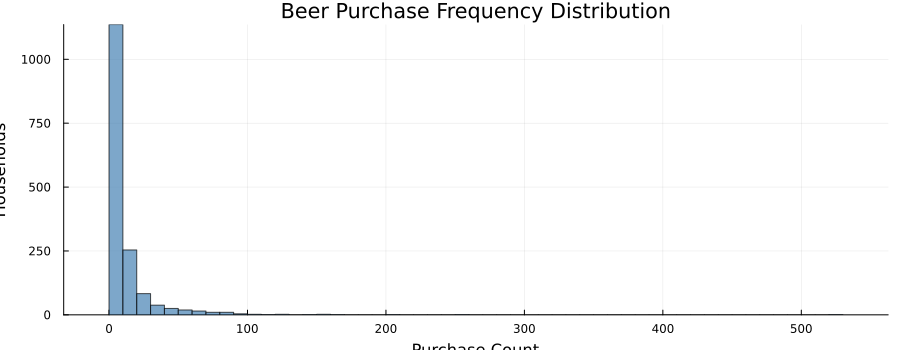

In [17]:
# 購買回数の分布
histogram(hh_freq.n_purchases, bins=50,
    xlabel="Purchase Count", ylabel="Households",
    title="Beer Purchase Frequency Distribution",
    label="", color=:steelblue, alpha=0.7,
    size=(900, 350))

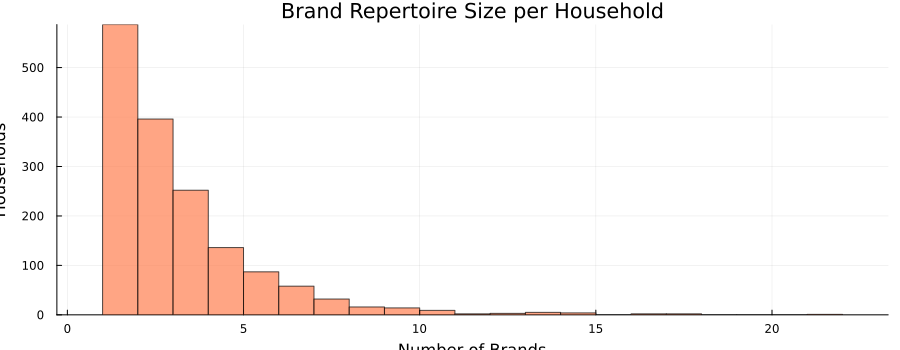

In [18]:
# 世帯あたり購入ブランド数の分布
histogram(hh_freq.n_brands, bins=maximum(hh_freq.n_brands),
    xlabel="Number of Brands", ylabel="Households",
    title="Brand Repertoire Size per Household",
    label="", color=:coral, alpha=0.7,
    size=(900, 350))

## 8. ブランド×世帯 購買マトリクス（Dirichlet分析用）

In [20]:
# 上位ブランドで世帯×ブランド購買回数マトリクスを作成
top_brands = first(brand_stats, 10).brand
top_data = filter(r -> r.brand in top_brands, beer_tx)

brand_matrix = unstack(
    combine(groupby(top_data, [:household_key, :brand]), nrow => :count),
    :household_key, :brand, :count, fill=0
)
@printf("世帯×ブランド マトリクス: %d × %d\n", nrow(brand_matrix), ncol(brand_matrix) - 1)
first(brand_matrix, 10)

世帯×ブランド マトリクス: 1559 × 10


Row,household_key,2384,239,1465,1728,2343,2431,697,1830,5221,2558
,String,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64,Int64
1,271,1,3,0,0,0,0,0,0,0,0
2,1060,0,4,1,0,0,0,0,0,0,0
3,2192,0,6,0,0,0,0,0,0,0,0
4,2324,0,3,0,1,2,0,0,0,0,0
5,293,0,1,0,0,0,0,0,0,0,0
6,315,0,1,0,0,0,0,0,0,0,0
7,924,0,6,0,0,0,0,0,0,0,0
8,1123,0,0,0,26,0,0,0,0,0,0
9,2110,2,0,0,0,3,0,2,1,0,0


In [21]:
using CSV
CSV.write("beer_brand_matrix.csv", brand_matrix)

"beer_brand_matrix.csv"

## 9. クローズ

In [ ]:
SQLite.close(db)
println("DB closed.")